# Introducción a Supervision - Sesión 28/05/26

Instalación de librerias requeridas

In [1]:
pip install supervision ultralytics

Note: you may need to restart the kernel to use updated packages.


Importamos librerias

In [2]:
import supervision as sv
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f"Supervision versión: {sv.__version__}")

Supervision versión: 0.28.0


Imagen cargada: (1080, 810, 3)


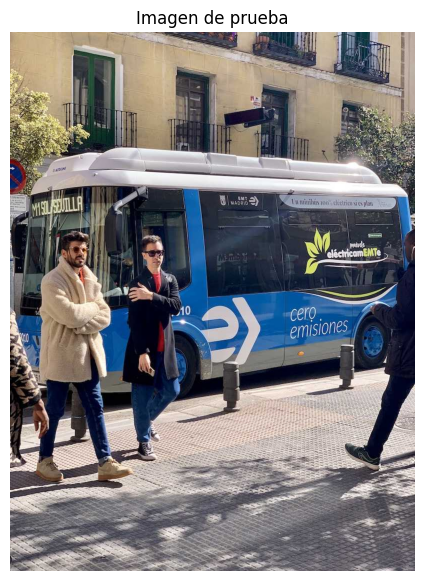

In [4]:
import urllib.request

Path("../../assets/curso/assets").mkdir(parents=True, exist_ok=True)

urllib.request.urlretrieve(
    "https://ultralytics.com/images/bus.jpg",
    "../../assets/curso/assets/bus.jpg"
)

image = cv2.imread("../../assets/curso/images/bus.jpg")
print(f"Imagen cargada: {image.shape}")

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Imagen de prueba")
plt.show()

Se carga el modelo YOLO

In [5]:
model = YOLO("../../assets/curso/models/yolov8n.pt")

Posteriormente analizamos la imagen, detectamos y convertimos con ultralytics

In [6]:
results = model(image)[0]
detections = sv.Detections.from_ultralytics(results)


0: 640x480 4 persons, 1 bus, 1 stop sign, 774.3ms
Speed: 142.8ms preprocess, 774.3ms inference, 64.2ms postprocess per image at shape (1, 3, 640, 480)


Imprimimos toda la información de las detecciones realizadas con el modelo YOLO

In [7]:
print(f"Número de objetos detectados: {len(detections)}")

print(f"\n--- xyxy: coordenadas del bounding box ---")
print("Formato: [x_izquierda, y_arriba, x_derecha, y_abajo]")
print(detections.xyxy)

print(f"\n--- confidence: certeza del modelo (0 = inseguro, 1 = muy seguro) ---")
print(detections.confidence)

print(f"\n--- class_id: número de la categoría detectada ---")
print(detections.class_id)

print(f"\n--- Traducción de class_id a nombre ---")
for class_id in sorted(set(detections.class_id)):
    print(f"  Clase {class_id}: {results.names[class_id]}")

Número de objetos detectados: 6

--- xyxy: coordenadas del bounding box ---
Formato: [x_izquierda, y_arriba, x_derecha, y_abajo]
[[     22.871      231.28         805      756.84]
 [      48.55      398.55      245.35       902.7]
 [     669.47      392.19      809.72      877.04]
 [     221.52       405.8      344.97      857.54]
 [          0      550.53      63.007      873.44]
 [   0.058167      254.46      32.557      324.87]]

--- confidence: certeza del modelo (0 = inseguro, 1 = muy seguro) ---
[    0.87345     0.86569     0.85284     0.82522     0.26111     0.25507]

--- class_id: número de la categoría detectada ---
[ 5  0  0  0  0 11]

--- Traducción de class_id a nombre ---
  Clase 0: person
  Clase 5: bus
  Clase 11: stop sign


Encontró 6 objetos, de los cuales nos da los bounding boxes de las detecciones.
La promedio de la certeza es de 80%-90%. De los 6 elementos detecto 4 personas con id 0, 1 autobus con id 5 y una señal de alto con id 11.

Una vez con estos datos podemos hacer las anotaciones que nos permitiran visualizar toda la información en imagen.

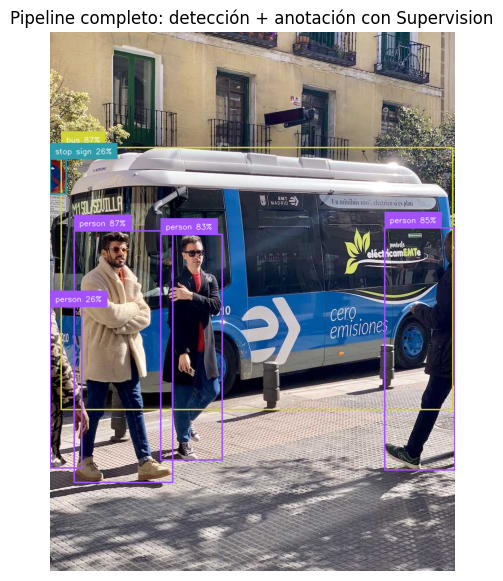

In [ ]:
box_annotator = sv.BoxAnnotator()   
label_annotator = sv.LabelAnnotator()

labels = [
    f"{results.names[class_id]} {conf:.0%}"
    for class_id, conf in zip(detections.class_id, detections.confidence)
]

annotated = box_annotator.annotate(scene=image.copy(), detections=detections)
annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Pipeline completo: detección + anotación con Supervision")
plt.show()

## Exploración interactiva

### Primer experimento
¿Que pasa cuando le pedimos al modelo que sea más estricto?

In [ ]:
results_estricto = model(image, conf=0.8)[0]
detections_estricto = sv.Detections.from_ultralytics(results_estricto)

print(f"Con conf=0.5 (por defecto): {len(detections)} objetos detectados")
print(f"Con conf=0.8 (estricto):    {len(detections_estricto)} objetos detectados")



0: 640x480 3 persons, 1 bus, 1378.1ms
Speed: 20.3ms preprocess, 1378.1ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 480)
Con conf=0.5 (por defecto): 6 objetos detectados
Con conf=0.8 (estricto):    4 objetos detectados


¿Por qué detecta menos objetos con confianza más alta? R: Porque el modelo solamente estaría resguardando los datos detectados que tiene mayor seguridad, y los demás datos donde la confianza es menor se pierden.

### Experimento 2: Inspeccionar una detección específica

In [ ]:
primera = detections[0]
# sv.Detections soporta indexación igual que una lista de Python
# primera es otro sv.Detections con un solo objeto

x1, y1, x2, y2 = primera.xyxy[0]
print(f"Primera detección:")
print(f"  Clase:    {results.names[primera.class_id[0]]}")
print(f"  Confianza: {primera.confidence[0]:.1%}")
print(f"  Posición:  esquina superior-izquierda ({x1:.0f}, {y1:.0f})")
print(f"             esquina inferior-derecha   ({x2:.0f}, {y2:.0f})")
print(f"  Tamaño:    {x2-x1:.0f} px de ancho × {y2-y1:.0f} px de alto")

#  Reflexión: Las coordenadas se miden en píxeles desde la esquina superior-izquierda.
# ¿Puedes estimar a qué objeto de la imagen corresponde esta detección? 

Primera detección:
  Clase:    bus
  Confianza: 87.3%
  Posición:  esquina superior-izquierda (23, 231)
             esquina inferior-derecha   (805, 757)
  Tamaño:    782 px de ancho × 526 px de alto


### Experimento 3: Cambiar el modelo

El código de Supervision no cambia al cambiar el modelo. Solo cambia la línea de YOLO.

In [22]:
model_s = YOLO("../../assets/curso/models/yolov8s.pt")  # ~22 MB — más preciso, más lento
results_s = model_s(image)[0]
detections_s = sv.Detections.from_ultralytics(results_s)

print(f"yolov8n (nano):  {len(detections)} objetos")
print(f"yolov8s (small): {len(detections_s)} objetos")

# 💭 Reflexión: ¿Detectan los mismos objetos? ¿Con la misma confianza?
# El modelo más grande suele detectar más objetos pequeños u ocluidos.


0: 640x480 4 persons, 1 bus, 1643.0ms
Speed: 87.1ms preprocess, 1643.0ms inference, 21.2ms postprocess per image at shape (1, 3, 640, 480)
yolov8n (nano):  6 objetos
yolov8s (small): 5 objetos


Es curioso que el modelo nano haya obtenido mayor detecciones que el modelo small, principalmente se debe que el modelo small requiere de una mayor confianza entre sus detecciones

## 🚀 Reto de extensión

**Tarea:** Ejecuta el pipeline completo con una imagen tuya o descargada de internet.

1. Descarga una imagen con `urllib.request.urlretrieve("URL", "mi_imagen.jpg")`
2. Cárgala con `cv2.imread("mi_imagen.jpg")`
3. Ejecuta el mismo pipeline (model → from_ultralytics → annotate)
4. ¿Qué objetos detecta? ¿Hay detecciones incorrectas?

Imagen cargada: (667, 1000, 3)


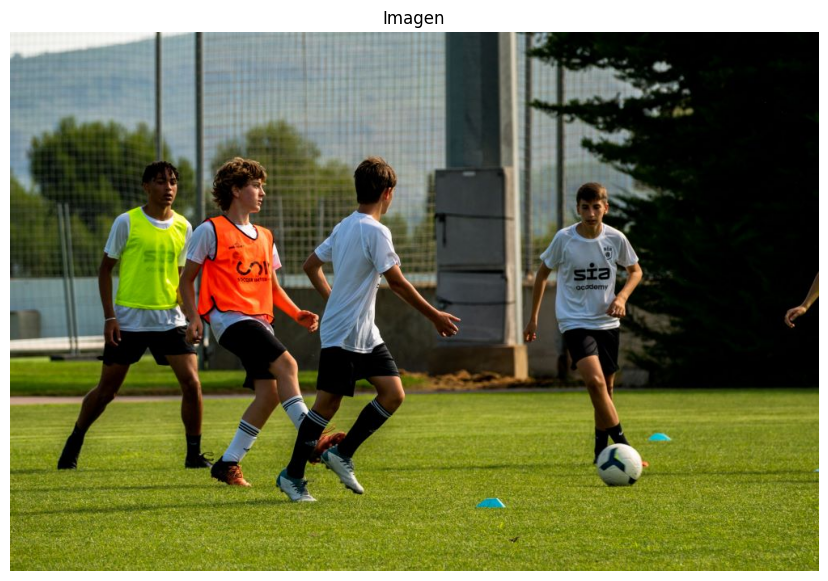

In [28]:
imagen_prueba = cv2.imread("../../assets/curso/images/imagen_001.jpg")
print(f"Imagen cargada: {imagen_prueba.shape}")

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(imagen_prueba, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Imagen")
plt.show()

In [ ]:
results_prueba = model(imagen_prueba)[0]
detections_prueba = sv.Detections.from_ultralytics(results_prueba)


0: 448x640 4 persons, 1 sports ball, 681.3ms
Speed: 87.4ms preprocess, 681.3ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


In [31]:
print(f"Número de objetos detectados: {len(detections)}")

print(f"\n--- xyxy: coordenadas del bounding box ---")
print("Formato: [x_izquierda, y_arriba, x_derecha, y_abajo]")
print(detections_prueba.xyxy)

print(f"\n--- confidence: certeza del modelo (0 = inseguro, 1 = muy seguro) ---")
print(detections_prueba.confidence)

print(f"\n--- class_id: número de la categoría detectada ---")
print(detections_prueba.class_id)

print(f"\n--- Traducción de class_id a nombre ---")
for class_id in sorted(set(detections.class_id)):
    print(f"  Clase {class_id}: {results.names[class_id]}")

Número de objetos detectados: 5

--- xyxy: coordenadas del bounding box ---
Formato: [x_izquierda, y_arriba, x_derecha, y_abajo]
[[     724.26      511.27      784.47      563.84]
 [     328.27       154.5      556.99      581.15]
 [     635.05       185.3      784.55      541.58]
 [     57.331      160.88      248.03       545.2]
 [     206.23      155.11      387.68      575.37]]

--- confidence: certeza del modelo (0 = inseguro, 1 = muy seguro) ---
[    0.93022     0.91668     0.90454     0.90016     0.80113]

--- class_id: número de la categoría detectada ---
[32  0  0  0  0]

--- Traducción de class_id a nombre ---
  Clase 0: person
  Clase 32: sports ball


Text(0.5, 1.0, 'Pipeline completo')

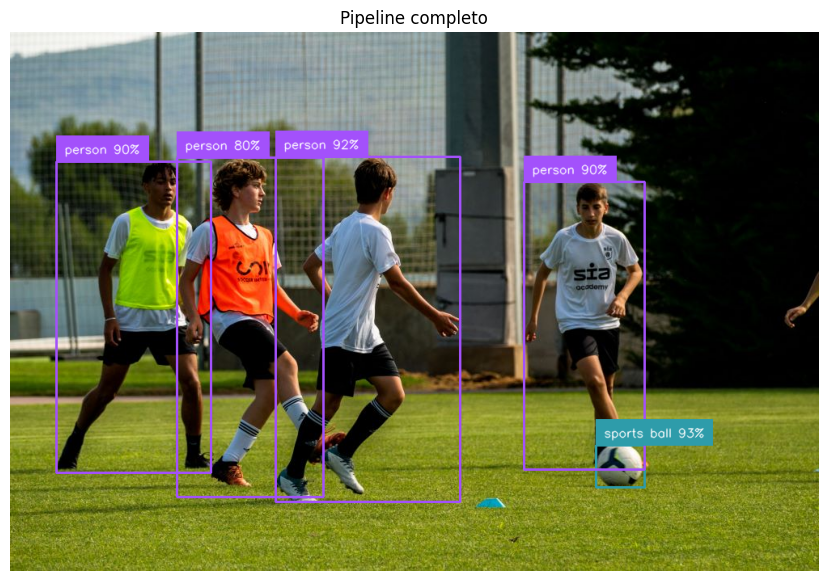

In [32]:
box_annotator_prueba = sv.BoxAnnotator()   
label_annotator_prueba = sv.LabelAnnotator()

labels = [
    f"{results.names[class_id]} {conf:.0%}"
    for class_id, conf in zip(detections_prueba.class_id, detections_prueba.confidence)
]

annotated = box_annotator_prueba.annotate(scene=imagen_prueba.copy(), detections=detections_prueba)
annotated = label_annotator_prueba.annotate(scene=annotated, detections=detections_prueba, labels=labels)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Pipeline completo")

### Guardar predicción en formato JSON

In [33]:
import json

def detections_to_dict(detections_prueba, class_names=None):
    """Convierte sv.Detections a un dict JSON-compatible."""
    return {
        "xyxy":        detections_prueba.xyxy.tolist(),
        "confidence":  detections_prueba.confidence.tolist() if detections_prueba.confidence is not None else None,
        "class_id":    detections_prueba.class_id.tolist() if detections_prueba.class_id is not None else None,
        "class_names": [class_names[c] for c in detections_prueba.class_id]
                       if (class_names and detections_prueba.class_id is not None) else None,
    }

resultado = detections_to_dict(detections_prueba, class_names=results.names)

with open("../../assets/curso/assets/predicciones.json", "w", encoding="utf-8") as f:
    json.dump(resultado, f, indent=2, ensure_ascii=False)

print("Guardado: ../../assets/curso/assets/predicciones.json")
print(json.dumps(resultado, indent=2, ensure_ascii=False))

Guardado: ../../assets/curso/assets/predicciones.json
{
  "xyxy": [
    [
      724.25732421875,
      511.27264404296875,
      784.4686889648438,
      563.8418579101562
    ],
    [
      328.2671203613281,
      154.50048828125,
      556.993896484375,
      581.154052734375
    ],
    [
      635.0531005859375,
      185.30178833007812,
      784.5457153320312,
      541.5836791992188
    ],
    [
      57.33070373535156,
      160.88360595703125,
      248.031005859375,
      545.2036743164062
    ],
    [
      206.23133850097656,
      155.1144561767578,
      387.6761779785156,
      575.3656616210938
    ]
  ],
  "confidence": [
    0.9302204251289368,
    0.9166759848594666,
    0.9045442938804626,
    0.9001553654670715,
    0.8011276125907898
  ],
  "class_id": [
    32,
    0,
    0,
    0,
    0
  ],
  "class_names": [
    "sports ball",
    "person",
    "person",
    "person",
    "person"
  ]
}
